# FFN: FOGD and NZK ZOGD (function space)

In [1]:
import torch
import torch.nn as nn

from matplotlib import pyplot as plt
import numpy as np

import copy, cv2
import os, time
from datasets import load_dataset
import skimage
from PIL import Image
from scipy.io import loadmat, savemat
torch.manual_seed(1)

eta_fo = 1e-3  # FOGD step size
eta_zo = 1e-3  # ZOGD step size

degree = 2
sample_num = 150

In [2]:
output_folder = os.path.join('output_FFN_zo_fo_ntk', 'ffn_nonlinear_degree_{}'.format(degree))
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

## Network, data, and targets

In [ ]:
class non_linear_function(nn.Module):
    def __init__(self, input_dim: int=2, hidden_dim: int = 5, output_dim: int = 1):
        super(non_linear_function, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, output_dim)
        self.acti = nn.ReLU()
        
        self.net = nn.Sequential(
            self.layer1,
            self.acti,
            self.layer2,
            self.acti,
            self.layer3,
        )
        
    def forward(self, x):
        mid = torch.tensor([])
        for layer in self.net:
            x = layer(x)
            mid = torch.cat((mid, x), dim=1)
        return x, mid
        

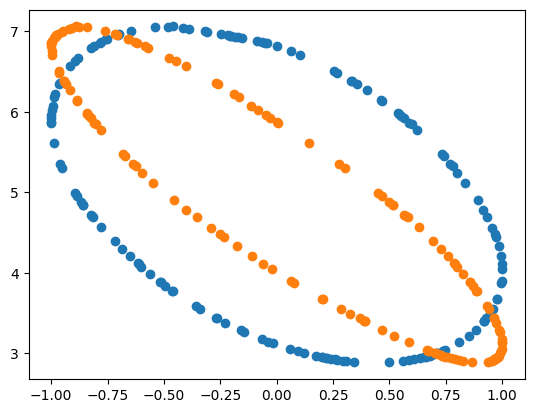

In [4]:
target_ffn_network = non_linear_function(input_dim=degree, hidden_dim=5, output_dim=1)
# random initialize all paratmeters in the network target_ffn_network
for param in target_ffn_network.parameters():
    param.data = torch.randn_like(param.data)

# copy the target_ffn_network to get the network for gradient descent method
gd_ffn_network = copy.deepcopy(target_ffn_network)

data_sample = torch.randn(sample_num, degree)
data_sample = data_sample / data_sample.norm(dim=1, keepdim=True, p=2)
target_gt = target_ffn_network(data_sample)[0]
plt.scatter(data_sample[:,0], target_gt.detach().numpy())
plt.scatter(data_sample[:,1], target_gt.detach().numpy())

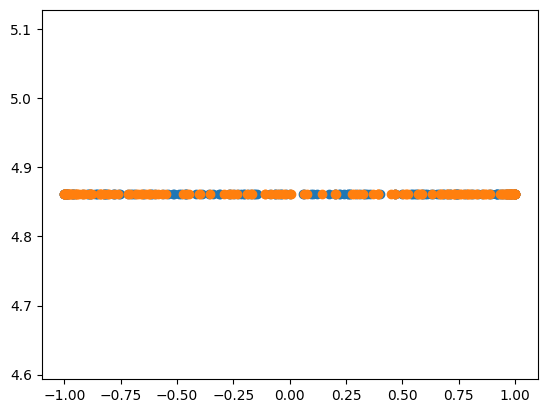

In [5]:
epoch = 10000
SGD_paramter_network = non_linear_function()
optimizer = torch.optim.Adam(params=SGD_paramter_network.parameters(), lr=1e-3)

for i in range(epoch):
    optimizer.zero_grad()
    y_pred, _ = SGD_paramter_network(data_sample)
    loss = 1/2 * torch.mean(torch.abs(y_pred - target_gt) ** 2)
    loss.backward(retain_graph=True)
    optimizer.step()
plt.scatter(data_sample[:,0], y_pred.detach().numpy())
plt.scatter(data_sample[:,1], y_pred.detach().numpy())

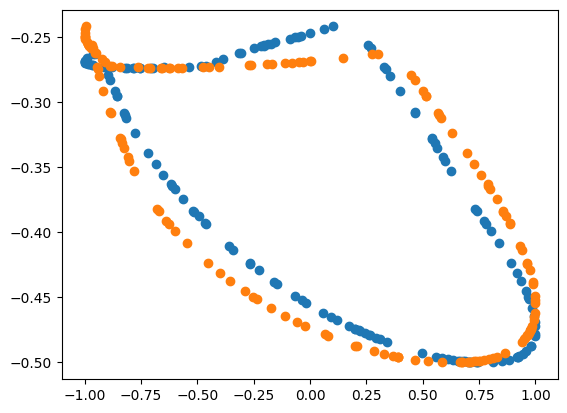

In [6]:
x_preprocessed = []

non_linear_model = non_linear_function(input_dim = degree, hidden_dim = 5, output_dim = 1)

theta_0 = torch.cat([p.reshape(-1) for p in non_linear_model.parameters()])

with torch.no_grad():
    model_0, _ = non_linear_model(data_sample)
    model_0 = model_0.detach()

for x_ in data_sample:
    non_linear_model.zero_grad()
    x_pred, mid = non_linear_model(x_.unsqueeze(0))
    gradient = torch.autograd.grad(x_pred, non_linear_model.parameters(), grad_outputs=torch.ones_like(x_pred), create_graph=True)
    x_preprocessed.append(torch.cat([gradient[i].reshape(-1) for i in range(len(gradient))]))

x_preprocessed = torch.stack(x_preprocessed)
x_preprocessed = x_preprocessed / x_preprocessed.norm(dim=1, keepdim=True, p=2)

N = x_preprocessed.shape[1]
x = copy.deepcopy(x_preprocessed.detach())
y = copy.deepcopy(target_gt.detach())

plt.scatter(data_sample[:,0], x_preprocessed.detach() @ theta_0.detach())
plt.scatter(data_sample[:,1], x_preprocessed.detach() @ theta_0.detach())

In [8]:
iteration_total = 30000
function_record_iteration_list = [0, 99, 999, 3999, 4999, 5999, 8999, 9999, iteration_total - 1]

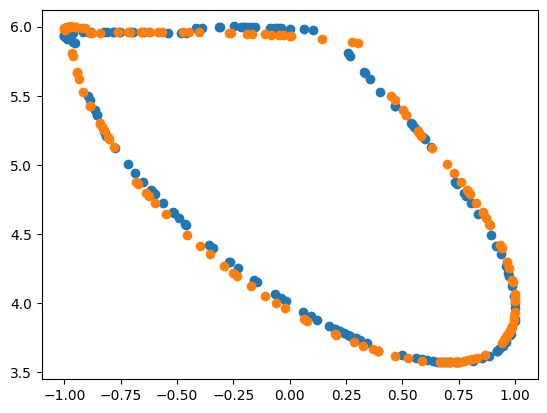

In [ ]:
loss_list_fo = torch.tensor([])
f_diff_list_fo = torch.tensor([])

NTK_kernal_fo = x @ x.t()

omiga_fo = copy.deepcopy(theta_0.detach()).view(-1, 1)
f_0 = x_preprocessed @ omiga_fo

f_fo_list = torch.Tensor([])

# fit 1000 
with torch.no_grad():
    for i in range(iteration_total):
        
        loss_0 = 1/2 * (f_0 - y).pow(2).mean() # compute the mean loss for whole dataset first
        loss_list_fo = torch.cat((loss_list_fo, loss_0.view(1)))
        
        f_1 = f_0 - eta_fo / sample_num * NTK_kernal_fo.T @ (f_0 - y)
        
        f_diff = f_1 - f_0
        f_0 = f_1
        
        if i in function_record_iteration_list:
            f_fo_list = torch.cat((f_fo_list, f_0.unsqueeze(0)))
    
        
        f_diff_list_fo = torch.cat((f_diff_list_fo, f_diff.view(1, -1)))
        
f_final = f_0

plt.scatter(data_sample[:,0], f_final)
plt.scatter(data_sample[:,1], f_final)

## NZK ZOGD

In [10]:
NTK_list_sample = torch.tensor([]).cuda()
x = x.cuda()

for i in range(10000):
    z = torch.normal(0.0, 1.0, size=(1, N)).cuda()
    z = z.repeat(sample_num, 1)
    
    first_term = z @ x.T
    second_term = z @ x.T
    third_term = z @ z.T
    
    NTK_zo_temp = first_term.T * second_term * third_term

    NTK_list_sample = torch.cat((NTK_list_sample, NTK_zo_temp.unsqueeze(0)))

    print("step", i) if i % 1000 == 0 else None
    
NZK_kernal_zo = NTK_list_sample.mean(dim=0).cpu()
x = x.cpu()

step 0
step 1000
step 2000
step 3000
step 4000
step 5000
step 6000
step 7000
step 8000
step 9000


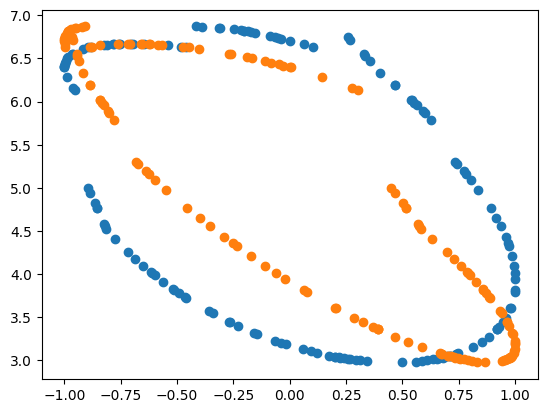

In [11]:
f_diff_list_zo = torch.tensor([])
loss_list_zo = torch.tensor([])
omiga_zo = copy.deepcopy(theta_0.detach()).view(-1, 1)

f_zo_list = torch.Tensor([])

f_0 = x_preprocessed @ omiga_zo

for i in range(iteration_total):

    loss_0 = 1/2 * (f_0 - y).pow(2).mean()
    loss_list_zo = torch.cat((loss_list_zo, loss_0.view(1)))
    
    f_1 = f_0 - eta_zo / sample_num * NZK_kernal_zo.T @ (f_0 - y)
    
    f_diff = f_1 - f_0
    f_diff_list_zo = torch.cat((f_diff_list_zo, f_diff.view(1, -1)))
    
    if i in function_record_iteration_list:
        f_zo_list = torch.cat((f_zo_list, f_0.unsqueeze(0)))
    
    f_0 = f_1

f_final = f_0 
plt.scatter(data_sample[:,0], f_final.detach())
plt.scatter(data_sample[:,1], f_final.detach())

In [12]:
# --------------------- save all data ---------------------
savemat(os.path.join(output_folder, 'data.mat'), {
    'data_sample': data_sample.numpy(),
    'target_gt': target_gt.detach().numpy(),
    'f_fo_list': f_fo_list.numpy(),
    'f_zo_list': f_zo_list.detach().numpy(),
    'loss_list_fo': loss_list_fo.numpy(),
    'loss_list_zo': loss_list_zo.detach().numpy(),
    'f_diff_list_fo': f_diff_list_fo.numpy(),
    'f_diff_list_zo': f_diff_list_zo.detach().numpy(),
    'function_record_iteration_list': function_record_iteration_list,
    'NTK_kernal_fo': NTK_kernal_fo.numpy(),
    'NZK_kernal_zo': NZK_kernal_zo.numpy()
})

# save the target_ffn_network parameters and network structure
torch.save(target_ffn_network, os.path.join(output_folder, 'target_ffn_network.pth'))

## Plots (2D)

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from matplotlib import cm
from mpl_toolkits.mplot3d.axes3d import get_test_data
from mpl_toolkits.axes_grid1 import make_axes_locatable

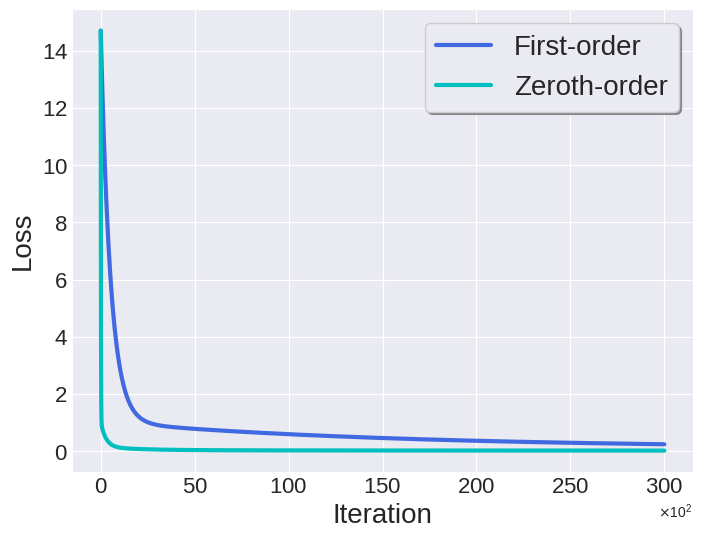

In [14]:
# plot the loss_list_fo and loss_list_zo
plt.style.use('seaborn-v0_8-darkgrid')

sf = plt.figure(figsize=(8,6), dpi=100)
ax = sf.add_subplot()
plt.plot(loss_list_fo[:].detach().numpy(),color='royalblue',label='First-order', linewidth=3)
plt.plot(loss_list_zo[:].detach().numpy(),color='c',label='Zeroth-order', linewidth=3)

plt.tick_params(axis='both', which='major', top='on', right='on', direction='in', labelsize=16)
plt.ticklabel_format(style='sci', scilimits=(0,2), axis='y',useMathText=True)
plt.ticklabel_format(style='sci', scilimits=(2,2), axis='x',useMathText=True)
plt.legend(fancybox=True, shadow=True,fontsize=20, frameon=True)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.show()

sf.savefig(os.path.join(output_folder,'loss.pdf'), bbox_inches='tight')

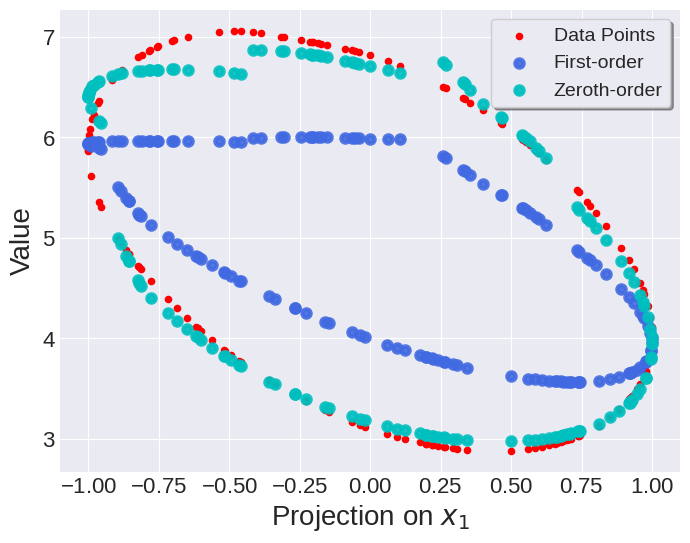

In [15]:
plt.style.use('seaborn-v0_8-darkgrid')
# plot the target function as a str
sf = plt.figure(figsize=(8,6))
ax = sf.add_subplot()

plt.scatter(data_sample[:, 0].detach().numpy(), target_gt.detach().numpy(), color='r', label='Data Points', s= 20)
# plot function learned by first order method
plt.scatter(data_sample[:, 0].detach().numpy(), f_fo_list[-1].detach().numpy(), color='royalblue', label='First-order', alpha=0.9, linewidth=3)
# ZO prediction
plt.scatter(data_sample[:, 0].detach().numpy(), f_zo_list[-1].detach().numpy(), color='c', label='Zeroth-order', alpha=0.9, linewidth=3)

plt.tick_params(axis='both', which='major', top='on', right='on', direction='in', labelsize=16)
plt.ticklabel_format(style='sci', scilimits=(-3,-2), axis='y',useMathText=True)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x',useMathText=True)
plt.legend(fancybox=True, shadow=True, fontsize=14, loc = 'upper right', frameon = True)
plt.xlabel(r'Projection on $x_1$', fontsize=20)
plt.ylabel('Value', fontsize=20)
plt.show()

sf.savefig(os.path.join(output_folder,'final_optimization.pdf'), bbox_inches='tight')

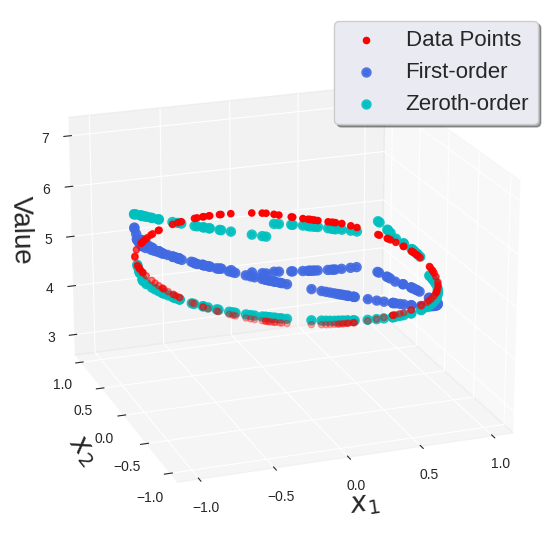

In [16]:
plt.style.use('seaborn-v0_8-darkgrid')
# plot the target function as a str
fig = plt.figure(figsize=(7,7))
f3d = fig.add_subplot(projection='3d')
# set background color as white
f3d.set_facecolor('white')



f3d.scatter(data_sample[:, 0].detach().numpy(), data_sample[:, 1].detach().numpy(), target_gt.detach().numpy(), color='r', label='Data Points', s= 20)
f3d.scatter(data_sample[:, 0].detach().numpy(), data_sample[:, 1].detach().numpy(), f_fo_list[-1].squeeze().detach().numpy(), color = 'royalblue', label='First-order',  linewidth=3, alpha=0.9)
f3d.scatter(data_sample[:, 0].detach().numpy(), data_sample[:, 1].detach().numpy(), f_zo_list[-1].squeeze().detach().numpy(), color = 'c', label='Zeroth-order', linewidth=3, alpha=0.9)
f3d.set_xlabel(r'$x_1$', fontsize=20)
f3d.set_ylabel(r'$x_2$', fontsize=20)
f3d.set_zlabel('Value', fontsize=20)
# show fewer x-ticks and y-ticks
f3d.locator_params(axis='x', nbins=8)
f3d.locator_params(axis='y', nbins=8)


f3d.legend(fancybox=True, shadow=True,fontsize=16, frameon = True, loc = 'upper right')


azim = int(-110)
dist = int(10)
elev = int(20)
if azim is not None:
    f3d.azim = azim
if dist is not None:
    f3d.dist = dist
if elev is not None:
    f3d.elev = elev

plt.show()
# save the figure
fig.savefig(os.path.join(output_folder,'final_optimization_3d.pdf'), bbox_inches='tight')

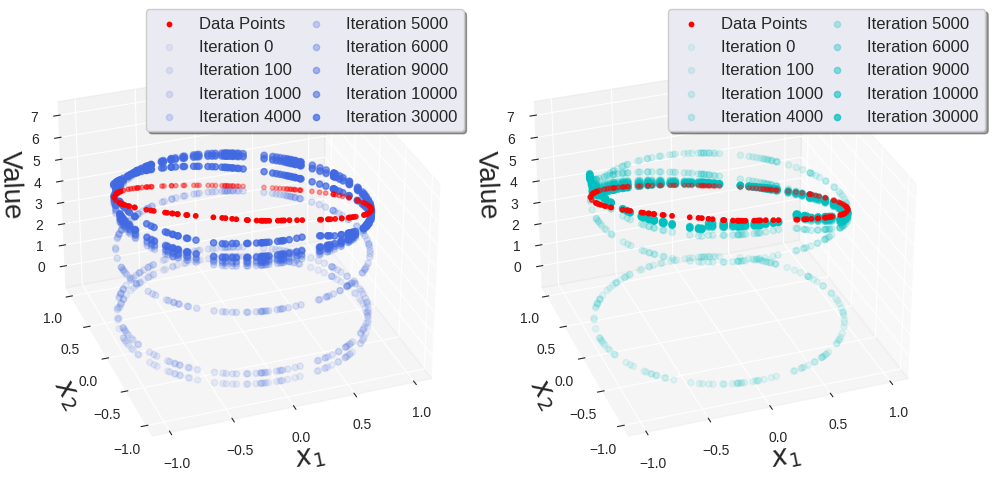

In [17]:
evolution_vis_style = 2 # do not use style 1 for clear visualization
# ---------------------------------------- style 1 ----------------------------------------
if evolution_vis_style == 1:
    rows = 2
    cols = len(f_zo_list)
    assert len(f_zo_list) == len(f_fo_list) == len(function_record_iteration_list)

    grid = plt.GridSpec(rows, cols, wspace = 0.05, hspace = 0.05)
    fig = plt.figure(figsize=(40,8))

    opacity = 0.1

    for i in range(len(function_record_iteration_list)):
        if i != 9:
            linestyle = 'dotted'
        else:
            linestyle = 'solid'
            
        # plot zo
        ax = fig.add_subplot(grid[0, i]) 
        ax.scatter(data_sample[:, 0].detach().numpy(), target_gt.detach().numpy(), color='r', label='Data Points', s= 20)
        ax.plot(data_sample[:, 0].detach().numpy(), f_zo_list[i].detach().numpy(), 'c', label='Zero-Order optimization', alpha=opacity, linestyle=linestyle)
        ax.set_title('Iteration {}'.format(function_record_iteration_list[i] + 1 if i != 0 else 0))
        ax.set_xticklabels([])
        if i == 0:
            ax.set_ylabel('Y', fontsize=14)
        else:
            ax.set_yticklabels([])
        ax.tick_params(axis='both', which='major', top='on', right='on', direction='in')
        ax.legend(fancybox=True, shadow=True,fontsize="10")
        
        # plot fo
        ax = fig.add_subplot(grid[1, i])
        ax.scatter(data_sample[:, 0].detach().numpy(), target_gt.detach().numpy(), color='r', label='Data Points', s= 20)
        ax.plot(data_sample[:, 0].detach().numpy(), f_fo_list[i].detach().numpy(), 'royalblue', label='First-Order optimization', alpha=opacity, linestyle=linestyle)
        
        ax.set_xlabel('X', fontsize=14)
        if i == 0:
            ax.set_ylabel('Y', fontsize=14)
        else:
            ax.set_yticklabels([])
        ax.tick_params(axis='both', which='major', top='on', right='on', direction='in')
        ax.legend(fancybox=True, shadow=True,fontsize="10")
        opacity += 0.1

# ---------------------------------------- style 2 ----------------------------------------

else:
    assert len(f_zo_list) == len(f_fo_list) == len(function_record_iteration_list)

    grid = plt.GridSpec(1, 2, wspace = 0.05, hspace = 0.05)
    fig = plt.figure(figsize=(12,6))
    opacity = 0.09
    
    # set background color as white
    fig.patch.set_facecolor('white')

    # plot zo
    ax = fig.add_subplot(grid[0, 0], projection='3d')
    ax.set_facecolor('white')
    ax.scatter(data_sample[:, 0].detach().numpy(), data_sample[:, 1].detach().numpy(), target_gt.detach().numpy(), color='r', label='Data Points', s= 10)

    for i in range(len(function_record_iteration_list)):
        if i != 8:
            linestyle = 'dotted'
        else:
            linestyle = 'solid'


        ax.scatter(data_sample[:, 0].detach().numpy(), data_sample[:, 1].detach().numpy(), f_fo_list[i].squeeze().detach().numpy(), color = 'royalblue', 
                label=f'Iteration {function_record_iteration_list[i] + 1 if i!=0 else 0}', alpha=opacity)
        ax.set_xlabel(r'$x_1$', fontsize=20)
        ax.set_ylabel(r'$x_2$', fontsize=20)
        ax.set_zlabel('Value', fontsize=20)
        ax.locator_params(axis='x', nbins=8)
        ax.locator_params(axis='y', nbins=8)
        ax.tick_params(axis='both', which='major', top='on', right='on', direction='in')
        ax.legend(fancybox=True, shadow=True,fontsize=12, loc='upper left', bbox_to_anchor=(.3, 1.02, 0.7, -0.0), ncol=2, mode="expand", borderaxespad=0, frameon=True)
        ax.set_facecolor('white')
        opacity *= 1.3
    
    azim = int(-110)
    dist = int(10)
    elev = int(30)
    if azim is not None:
        ax.azim = azim
    if dist is not None:
        ax.dist = dist
    if elev is not None:
        ax.elev = elev

    # plot fo
    opacity = 0.09
    ax = fig.add_subplot(grid[0, 1], projection='3d')
    ax.scatter(data_sample[:, 0].detach().numpy(), data_sample[:, 1].detach().numpy(), target_gt.detach().numpy(), color='r', label='Data Points', s= 10)
    for i in range(len(function_record_iteration_list)):
        if i != 8:
            linestyle = 'dotted'
        else:
            linestyle = 'solid'
        
        ax.scatter(data_sample[:, 0].detach().numpy(), data_sample[:, 1].detach().numpy(), f_zo_list[i].squeeze().detach().numpy(), color = 'c', 
                label=f'Iteration {function_record_iteration_list[i] + 1 if i!=0 else 0}', alpha=opacity)
        ax.set_xlabel(r'$x_1$', fontsize=20)
        ax.set_ylabel(r'$x_2$', fontsize=20)
        ax.set_zlabel('Value', fontsize=20)
        
        ax.locator_params(axis='x', nbins=8)
        ax.locator_params(axis='y', nbins=8)
        ax.tick_params(axis='both', which='major', top='on', right='on', direction='in', labelsize=10)
        ax.legend(fancybox=True, shadow=True,fontsize=12, loc='upper left', bbox_to_anchor=(.4, 1.02, 0.7, -0.0), ncol=2, mode="expand", borderaxespad=0, frameon=True)
        ax.set_facecolor('white')
        opacity *= 1.3
    
    azim = int(-110)
    dist = int(10)
    elev = int(30)
    if azim is not None:
        ax.azim = azim
    if dist is not None:
        ax.dist = dist
    if elev is not None:
        ax.elev = elev

plt.show()
fig.savefig(os.path.join(output_folder,f'Evolution_process_style{evolution_vis_style}.pdf'), bbox_inches='tight')

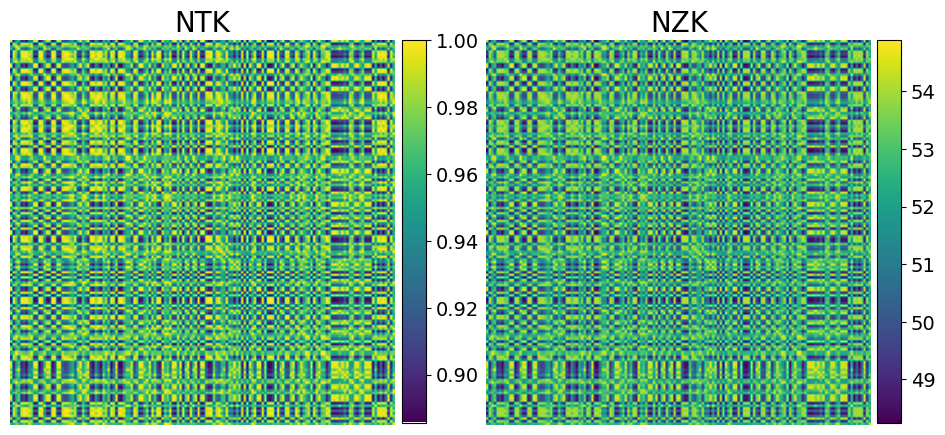

In [18]:
# return to defualt style
plt.style.use('default')
grid = plt.GridSpec(1, 2, wspace = 0.05, hspace = 0.05)

fig = plt.figure(figsize=(12,5))

ax = fig.add_subplot(grid[0, 0])
norm_fo = plt.Normalize(NTK_kernal_fo.min(), NTK_kernal_fo.max())
ax.imshow(NTK_kernal_fo.detach().numpy(), label='NTK')
ax.title.set_text('NTK')
ax.title.set_fontsize(20)
ax.axis('off')
cbar_ax = fig.add_axes([0.48, 0.115, 0.02, 0.765])
cbar_ax.tick_params(labelsize=14)
sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm_fo)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)


ax = fig.add_subplot(grid[0, 1])
norm_zo = plt.Normalize(NZK_kernal_zo.min(), NZK_kernal_zo.max())
ax.imshow(NZK_kernal_zo.detach().numpy(), label='NZK')
ax.title.set_text('NZK')
ax.title.set_fontsize(20)
ax.axis('off')
# add colorbar

# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
cbar_ax = fig.add_axes([0.876, 0.115, 0.02, 0.765])
cbar_ax.tick_params(labelsize=14)
sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm_zo)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)
plt.show()
fig.savefig(os.path.join(output_folder,'NTK_NZK.pdf'), bbox_inches='tight')